# TP3 - Análisis de Sentimiento sobre Tweets (Sentiment140)
## Notebook 0 — Primera Lectura y EDA Inicial
### Diplomatura en IA - UP
### Alumno: Gonzalez Marta Elizabeth
### Mes: Julio26

**Este notebook es independiente del resto del pipeline** (no genera ni consume archivos intermedios de los notebooks 01-05). Su único objetivo es dar una **primera mirada cruda** a los datasets originales, tal como llegan, antes de tomar ninguna decisión de limpieza, unión o modelado — nulos, duplicados, outliers, y primeras relaciones entre variables.

### Datasets
| Archivo | Filas aprox. | Rol |
|---|---|---|
| `testdata_manual_2009_06_14.csv` | 498 | Test manual oficial de Sentiment140 (3 clases) |
| `training.1600000.processed.noemoticon.csv` | 1.6M | Dataset completo original |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_colwidth', 120)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (9,5)

#RUTA:
RAW_TRAIN_PATH = '../data/raw/training.1600000.processed.noemoticon.csv'
RAW_MANUAL_PATH = '../data/raw/testdata_manual_2009_06_14.csv'

COLS = ['target', 'id', 'date', 'flag', 'user', 'text']


## 1. Primera lectura de cada dataset (por separado, sin ningún procesamiento)

In [2]:
manual = pd.read_csv(RAW_MANUAL_PATH, encoding='latin-1', names=COLS, header=0)
train_1_6m = pd.read_csv(RAW_TRAIN_PATH, encoding='latin-1', names=COLS, header=None, low_memory=False)

# El archivo de 1.6M a veces trae una fila de encabezado mezclada como dato -> la limpiamos acá
train_1_6m['target'] = pd.to_numeric(train_1_6m['target'], errors='coerce')
train_1_6m = train_1_6m.dropna(subset=['target']).copy()
train_1_6m['target'] = train_1_6m['target'].astype(int)

datasets = {
    'testdata_manual': manual,
    'training_1.6M': train_1_6m,
}

for nombre, df in datasets.items():
    print(f'{nombre}: {df.shape[0]} filas, {df.shape[1]} columnas')


testdata_manual: 498 filas, 6 columnas
training_1.6M: 1600000 filas, 6 columnas


In [3]:
print('=== testdata_manual — primeras filas ===')
manual.head()


=== testdata_manual — primeras filas ===


,target,id,date,flag,user,text
0,4,3,Mon May 11 03:17:40 UTC 2009,kindle2,tpryan,"@stellargirl I loooooooovvvvvveee my Kindle2. Not that the DX is cool, but the 2 is fantastic in its own right."
1,4,4,Mon May 11 03:18:03 UTC 2009,kindle2,vcu451,Reading my kindle2... Love it... Lee childs is good read.
2,4,5,Mon May 11 03:18:54 UTC 2009,kindle2,chadfu,"Ok, first assesment of the #kindle2 ...it fucking rocks!!!"
3,4,6,Mon May 11 03:19:04 UTC 2009,kindle2,SIX15,@kenburbary You'll love your Kindle2. I've had mine for a few months and never looked back. The new big one is huge!...
4,4,7,Mon May 11 03:21:41 UTC 2009,kindle2,yamarama,@mikefish Fair enough. But i have the Kindle2 and I think it's perfect :)


In [4]:
print('=== training_1.6M — primeras filas ===')
train_1_6m.head()


=== training_1.6M — primeras filas ===


,target,id,date,flag,user,text
1,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer. You shoulda got David Carr of Third Day to do it. ;D"
2,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by texting it... and might cry as a result School today also. Blah!
3,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Managed to save 50% The rest go out of bounds
4,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
5,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all. i'm mad. why am i here? because I can't see you all over there."


## 2. Primeros hallazgos: tipos de dato, nulos, duplicados

In [5]:
for nombre, df in datasets.items():
    print(f'--- {nombre} ---')
    print(df.dtypes)
    print(f'Nulos totales: {df.isnull().sum().sum()}')
    if df.isnull().sum().sum() > 0:
        print(df.isnull().sum()[df.isnull().sum() > 0])
    print(f'Duplicados por texto: {df["text"].duplicated().sum()} ({df["text"].duplicated().sum()/len(df):.2%})')
    print(f'Duplicados por id: {df["id"].duplicated().sum()}')
    print()


--- testdata_manual ---
target     int64
id         int64
date      object
flag      object
user      object
text      object
dtype: object
Nulos totales: 0
Duplicados por texto: 0 (0.00%)
Duplicados por id: 0

--- training_1.6M ---
target     int64
id        object
date      object
flag      object
user      object
text      object
dtype: object
Nulos totales: 0
Duplicados por texto: 18534 (1.16%)
Duplicados por id: 1685



In [6]:
print('=== Distribución de clases (target) por dataset ===')
for nombre, df in datasets.items():
    print(f'\n{nombre}:')
    print(df['target'].value_counts())


=== Distribución de clases (target) por dataset ===

testdata_manual:
target
4    182
0    177
2    139
Name: count, dtype: int64

training_1.6M:
target
0    800000
4    800000
Name: count, dtype: int64


**Primeros hallazgos:**
- `testdata_manual` es el único con **3 clases** (incluye neutral=2).
- Ninguno de los dos tiene valores nulos, lo cual es razonable para un dataset de tweets con columnas siempre completadas automáticamente al momento del scraping.
- Puede haber tweets duplicados en texto (retweets/copias) — se cuantifican arriba; no son errores de carga, sino repeticiones reales de contenido en redes sociales.

## 3. Variables numéricas rápidas para EDA (solo para esta exploración inicial)

Para poder graficar outliers y relaciones, calculamos dos variables numéricas simples directamente sobre el texto crudo — esto **no** es la limpieza definitiva (que se hace recién en el Notebook 1), es solo para tener algo numérico que explorar acá.

In [8]:
for nombre, df in datasets.items():
    df['n_chars'] = df['text'].str.len()
    df['n_words'] = df['text'].str.split().str.len()

# Unificamos en un solo DataFrame para graficar más cómodo, con una columna que identifica el origen
manual['dataset'] = 'testdata_manual'
train_1_6m['dataset'] = 'training_1.6M'

todos = pd.concat([manual, train_1_6m], ignore_index=True)
todos[['dataset','n_chars','n_words']].groupby('dataset').describe().T


dataset        testdata_manual  training_1.6M
n_chars count       498.000000   1.600000e+06
        mean         80.411647   7.408120e+01
        std          35.790319   3.643503e+01
        min          11.000000   6.000000e+00
        25%          53.250000   4.400000e+01
        50%          75.000000   6.900000e+01
        75%         108.000000   1.040000e+02
        max         144.000000   3.630000e+02
n_words count       498.000000   1.600000e+06
        mean         13.554217   1.318052e+01
        std           6.604528   6.961521e+00
        min           2.000000   1.000000e+00
        25%           8.000000   7.000000e+00
        50%          12.000000   1.200000e+01
        75%          18.000000   1.900000e+01
        max          30.000000   1.170000e+02

## 4. Boxplots — detección de outliers

C:\Users\Usuario\AppData\Local\Temp\ipykernel_20524\2542683959.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=todos, x='dataset', y='n_chars', ax=axes[0], palette='Set2')
C:\Users\Usuario\AppData\Local\Temp\ipykernel_20524\2542683959.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=todos, x='dataset', y='n_words', ax=axes[1], palette='Set2')


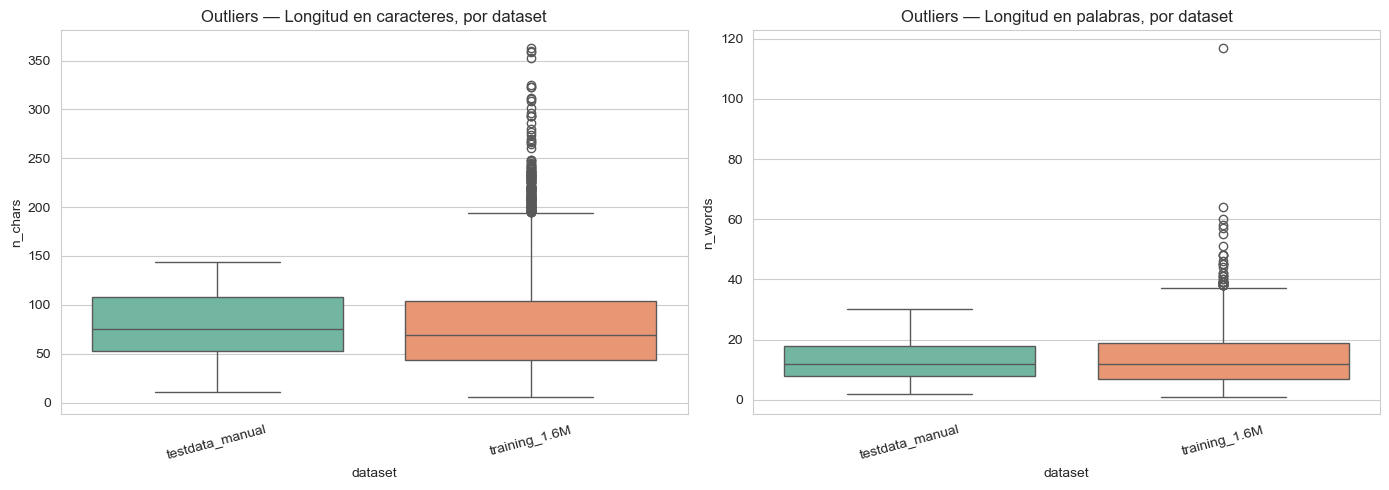

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.boxplot(data=todos, x='dataset', y='n_chars', ax=axes[0], palette='Set2')
axes[0].set_title('Outliers — Longitud en caracteres, por dataset')
axes[0].tick_params(axis='x', rotation=15)

sns.boxplot(data=todos, x='dataset', y='n_words', ax=axes[1], palette='Set2')
axes[1].set_title('Outliers — Longitud en palabras, por dataset')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('outputs_nb0_boxplots_outliers.png', dpi=110, bbox_inches='tight')
plt.show()


In [10]:
# Cuantificación de outliers via rango intercuartil (IQR), sobre el dataset completo de 1.6M
q1, q3 = train_1_6m['n_chars'].quantile([0.25, 0.75])
iqr = q3 - q1
limite_inferior, limite_superior = q1 - 1.5*iqr, q3 + 1.5*iqr
outliers = train_1_6m[(train_1_6m['n_chars'] < limite_inferior) | (train_1_6m['n_chars'] > limite_superior)]

print(f'Rango normal (IQR) de longitud en caracteres: [{limite_inferior:.0f}, {limite_superior:.0f}]')
print(f'Outliers detectados: {len(outliers)} ({len(outliers)/len(train_1_6m):.2%})')
outliers[['text','n_chars']].sort_values('n_chars', ascending=False).head(5)


Rango normal (IQR) de longitud en caracteres: [-46, 194]
Outliers detectados: 143 (0.01%)


,text,n_chars
1295282,@catfish_ohm à¹à¸à¹à¸²à¹à¸«à¹ ?à¸²à¸£à¹à¸à¸¹à¸ ?à¸¸à¹à¸£à¸°(à¸ªà¸±à¸ªà¹+à¸¢à¸¹à¸£à¸´ ? ?à¹à¸à¹ ?à¸à¸à...,363
1484883,@iannnnn à¹à¸à¸µà¹à¸¢à¸§à¸­à¸µ ?à¸à¸± ?à¸à¸£à¸¹à¹à¸à¸à¹à¸£à¸µà¸¢ ?à¸à¸µà¸¡ Graphic à¹à¸à¹à¸²à¸¡à¸² ?à¸¥...,360
1582942,5 days till new top gear ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ...,359
380540,@neospace à¹à¸£à¸·à¹à¸­à¸à¸à¸±à¹à¸à¸à¸£à¸£à¸à¹à¸à¸£à¸² à¹à¸«à¹à¸à¸à¹à¸§à¸¢à¸à¸µà¹à¹à¸¡à¹à¸à¹à¸­...,353
1450936,@KaewGB à¸­à¹à¸­ à¹à¸à¸¢à¸à¸²à¸¡à¹à¹à¸à¸à¸µà¹à¸«à¸¥à¸²à¸¢à¸à¸£à¸±à¹à¸ à¹à¸¡à¹à¸¡à¸µà¹à¸à¸£à¸à¸¹à¸...,325


**Observación:** Twitter en 2009 tenía un límite de 140 caracteres, así que no deberíamos ver outliers extremos por *exceso* de longitud — si aparecen, probablemente sean tweets con URLs largas sin acortar o texto pegado sin espacios. Los outliers por *defecto* (tweets muy cortos) suelen ser tweets que son solo una URL, una mención, o una interjección corta ("lol", "ugh").

## 5. Boxplot de longitud por clase de sentimiento (relación entre variables)

C:\Users\Usuario\AppData\Local\Temp\ipykernel_20524\3491500713.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train_1_6m, x='target', y='n_chars', order=orden_clases, palette='coolwarm', ax=ax)
C:\Users\Usuario\AppData\Local\Temp\ipykernel_20524\3491500713.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Negativo' if c==0 else 'Neutral' if c==2 else 'Positivo' for c in orden_clases])


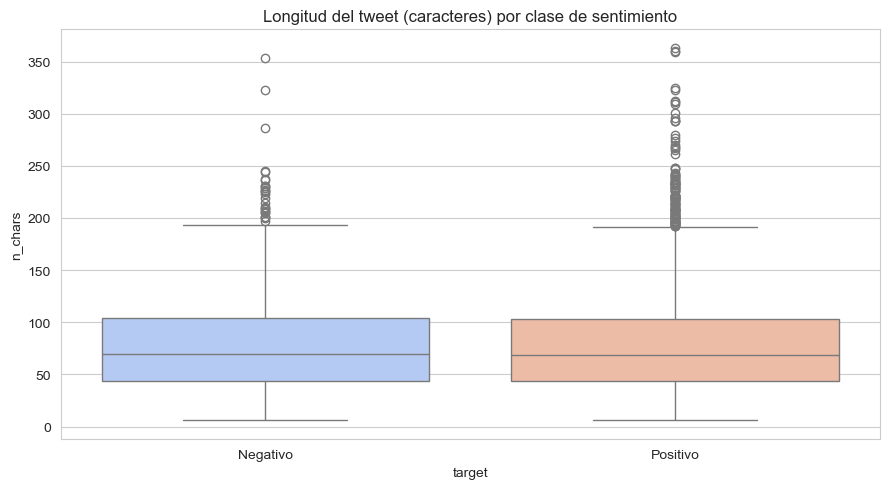

In [11]:
fig, ax = plt.subplots(figsize=(9,5))
orden_clases = sorted(train_1_6m['target'].unique())
sns.boxplot(data=train_1_6m, x='target', y='n_chars', order=orden_clases, palette='coolwarm', ax=ax)
ax.set_xticklabels(['Negativo' if c==0 else 'Neutral' if c==2 else 'Positivo' for c in orden_clases])
ax.set_title('Longitud del tweet (caracteres) por clase de sentimiento')
plt.tight_layout()
plt.savefig('outputs_nb0_longitud_por_clase.png', dpi=110, bbox_inches='tight')
plt.show()


## 6. Relación entre variables: usuarios más activos

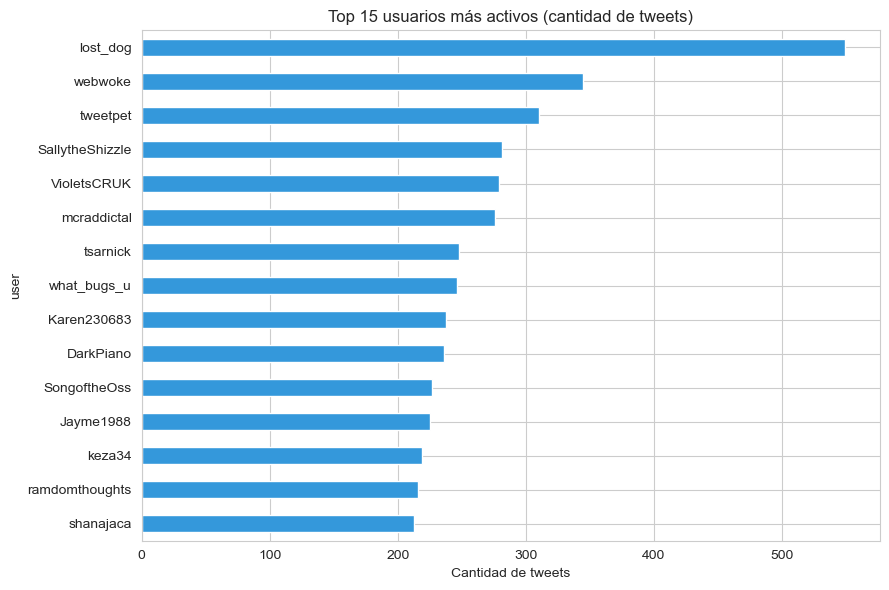

Usuarios únicos: 659775 sobre 1600000 tweets
Promedio de tweets por usuario: 2.43


In [12]:
top_usuarios = train_1_6m['user'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(9,6))
top_usuarios.plot(kind='barh', ax=ax, color='#3498db')
ax.set_title('Top 15 usuarios más activos (cantidad de tweets)')
ax.set_xlabel('Cantidad de tweets')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('outputs_nb0_top_usuarios.png', dpi=110, bbox_inches='tight')
plt.show()

print(f'Usuarios únicos: {train_1_6m["user"].nunique()} sobre {len(train_1_6m)} tweets')
print(f'Promedio de tweets por usuario: {len(train_1_6m)/train_1_6m["user"].nunique():.2f}')


## 7. Relación entre variables: cantidad de tweets por día

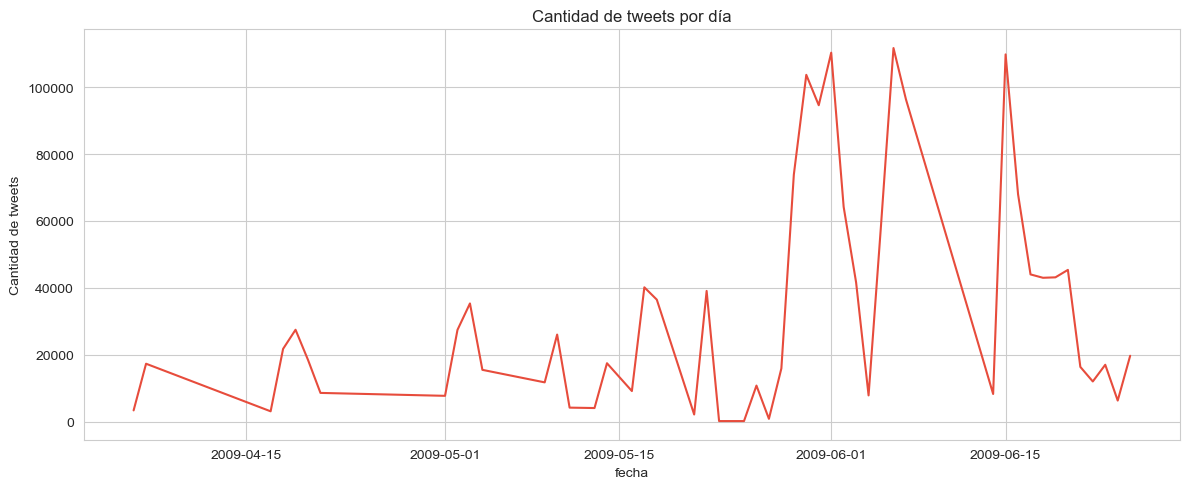

In [13]:
def parse_twitter_date(s):
    parts = str(s).split()
    s2 = ' '.join(parts[:4] + parts[5:])
    try:
        return pd.to_datetime(s2, format='%a %b %d %H:%M:%S %Y')
    except Exception:
        return pd.NaT

train_1_6m['datetime'] = train_1_6m['date'].apply(parse_twitter_date)
train_1_6m['fecha'] = train_1_6m['datetime'].dt.date

tweets_por_dia = train_1_6m.groupby('fecha').size()

fig, ax = plt.subplots(figsize=(12,5))
tweets_por_dia.plot(ax=ax, color='#e74c3c')
ax.set_title('Cantidad de tweets por día')
ax.set_ylabel('Cantidad de tweets')
plt.tight_layout()
plt.savefig('outputs_nb0_tweets_por_dia.png', dpi=110, bbox_inches='tight')
plt.show()


## 8. Relación entre variables: mapa de calor de correlación (longitud, target)

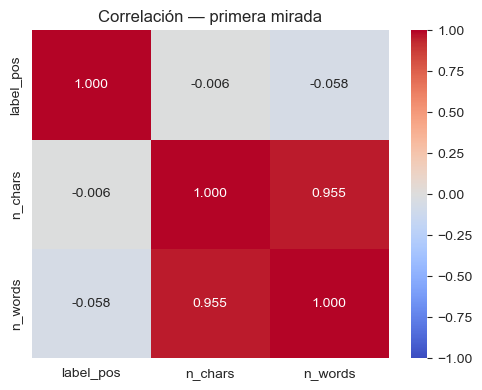

In [14]:
train_1_6m['label_pos'] = (train_1_6m['target'] == 4).astype(int)
corr = train_1_6m[['label_pos', 'n_chars', 'n_words']].corr()

fig, ax = plt.subplots(figsize=(5,4))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm', center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title('Correlación — primera mirada')
plt.tight_layout()
plt.show()


## 9. Conclusiones preliminares de esta primera exploración

1. Ningún dataset tiene nulos; puede haber duplicados de texto (retweets/contenido repetido), no son errores de carga.
3. Hay outliers de longitud tanto por exceso (URLs largas / texto sin espacios) como por defecto (tweets muy cortos) — se identificaron con el criterio de rango intercuartílico (IQR).
4. La longitud del tweet no muestra una relación fuerte con la clase de sentimiento a simple vista (correlación cercana a 0) — se confirma con más detalle en el Notebook 1.
5. La actividad por usuario está concentrada: pocos usuarios muy activos generan una porción desproporcionada de tweets — algo para tener en cuenta en el análisis de grafos del Notebook 5 (usuarios "hub").
6. El volumen de tweets por día varía bastante — hay días con picos notorios, que se retoman con más detalle en el análisis temporal del Notebook 1 y en la evolución de la red de menciones del Notebook 5.

**Este notebook no genera ningún archivo para los siguientes** — es exploración pura. El pipeline real arranca en `01_union_eda_preprocesamiento.ipynb`.